In [1]:
import cfgrib
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import re
import glob
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.patches import Rectangle

# Prepare datafiles 
This script combines downloaded GRIB files containing static, surface, height and pressure level variables into one zarr and netcdf file (per month).
!Important: CERRA data is on a Lambert Conformal Conic (LCC) projected grid, not regular lat/lon.

## Helper functions 

In [46]:
#Bound cerra data to domain of interest 
def index_box(ds, lat_min=49, lat_max=56, lon_min=-6, lon_max=10):
    lat = ds["latitude"].values   # 2-D (y, x)
    lon = ds["longitude"].values  # 2-D (y, x)

    # Convert longitudes from 0–360 to -180–180 if needed
    if np.any(lon > 180):
        lon = ((lon + 180) % 360) - 180

    if lat_min > lat_max:
        lat_min, lat_max = lat_max, lat_min
    if lon_min > lon_max:
        lon_min, lon_max = lon_max, lon_min

    m = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    if not np.any(m):
        raise ValueError("No grid points found within the specified lat/lon box. Check coordinates!")

    yy, xx = np.where(m)
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())

    return slice(y0, y1 + 1), slice(x0, x1 + 1)

#crop a list of xarray datasets to the right size 
def crop(datasets):
    cropped = []
    for ds in datasets:
        ys, xs = index_box(ds)
        dsc = ds.isel(y=ys, x=xs)  # hard crop, no masking → no NaNs

        if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
            dsc = dsc.reset_coords("heightAboveGround", drop=True)
            dsc=dsc.squeeze()
        cropped.append(dsc)
    aligned = xr.align(*cropped, join="inner")  # keep only common coords (e.g., time)
    ds = xr.merge(aligned, compat="override", combine_attrs="drop")
    return ds

def dir_to_sin_cos(da_deg: xr.DataArray):
    """Return sin, cos of a direction in degrees. Keeps dims/coords."""
    rad = np.deg2rad((da_deg % 360))
    return np.sin(rad), np.cos(rad)

## Load in different datasets 

### Surface files 

In [16]:
data_sfc = cfgrib.open_datasets(
    "./oldfiles/CERRA5_sfc.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [17]:
surface = crop(data_sfc)
surface = surface.drop_vars('sr')

In [25]:
surface

<xarray.Dataset> Size: 4GB
Dimensions:           (time: 5360, y: 157, x: 211)
Coordinates:
  * time              (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T21...
    step              timedelta64[ns] 8B 00:00:00
    entireAtmosphere  float64 8B 0.0
    latitude          (y, x) float64 265kB 48.17 48.18 48.19 ... 56.69 56.69
    longitude         (y, x) float64 265kB 354.3 354.4 354.4 ... 10.24 10.33
    valid_time        (time) datetime64[ns] 43kB ...
    meanSea           float64 8B 0.0
    surface           float64 8B 0.0
Dimensions without coordinates: y, x
Data variables:
    mcc               (time, y, x) float32 710MB ...
    t2m               (time, y, x) float32 710MB ...
    si10              (time, y, x) float32 710MB ...
    wdir10            (time, y, x) float32 710MB ...
    msl               (time, y, x) float32 710MB ...
    orog              (time, y, x) float32 710MB ...

### Height files

In [19]:
data_height= cfgrib.open_datasets(
    "./oldfiles/Cerra_height.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [20]:
height = crop(data_height)

In [26]:
height

<xarray.Dataset> Size: 6GB
Dimensions:            (time: 5360, heightAboveGround: 4, y: 157, x: 211)
Coordinates:
  * time               (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T2...
    step               timedelta64[ns] 8B 00:00:00
  * heightAboveGround  (heightAboveGround) float64 32B 50.0 100.0 150.0 200.0
    latitude           (y, x) float64 265kB 48.17 48.18 48.19 ... 56.69 56.69
    longitude          (y, x) float64 265kB 354.3 354.4 354.4 ... 10.24 10.33
    valid_time         (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T2...
Dimensions without coordinates: y, x
Data variables:
    ws                 (time, heightAboveGround, y, x) float32 3GB ...
    wdir               (time, heightAboveGround, y, x) float32 3GB ...

### Static files 

In [21]:
data_static = cfgrib.open_datasets(
    "./cerra_boz/raw_grib/cerra_static.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [22]:
static = crop(data_static)

In [27]:
static

<xarray.Dataset> Size: 795kB
Dimensions:     (y: 157, x: 211)
Coordinates:
    time        datetime64[ns] 8B 2020-01-01
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
    latitude    (y, x) float64 265kB 48.17 48.18 48.19 ... 56.69 56.69 56.69
    longitude   (y, x) float64 265kB 354.3 354.4 354.4 ... 10.15 10.24 10.33
    valid_time  datetime64[ns] 8B 2020-01-01
Dimensions without coordinates: y, x
Data variables:
    lsm         (y, x) float32 133kB ...
    orog        (y, x) float32 133kB ...

### Pressure levels 

In [23]:
# data_pressure = cfgrib.open_datasets(
#     "./cerra_boz/raw_grib/cerra_pressure_2024_01.grib",
#     backend_kwargs={"indexpath": "", "decode_timedelta": True},
# )

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [24]:
pressure= crop(data_pressure)

### Merge

In [30]:
cerra = xr.merge([static,height,pressure,surface],compat="override")
cerra = cerra.load()

In [47]:
base = "/mnt/data/weatherloss/WindPower/data/cerra_boz/nc_boz"

surface_files  = sorted(glob.glob(os.path.join(base, "cerra_single_????_??_BOZ.nc")))
height_files   = sorted(glob.glob(os.path.join(base, "cerra_height_????_??_BOZ.nc")))
pressure_files = sorted(glob.glob(os.path.join(base, "cerra_pressure_????_??_BOZ.nc")))
static_file    = os.path.join(base, "cerra_static_BOZ.nc")

print(f"{len(surface_files)} surface files, {len(height_files)} height files, {len(pressure_files)} pressure files")

def _pp(ds):
    drop_candidates = ["valid_time", "step", "surface", "meanSea", "entireAtmosphere"]
    drops = [v for v in drop_candidates if v in ds.variables or v in ds.coords]
    return ds.drop_vars(drops, errors="ignore")

ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
ds_hgt = xr.open_mfdataset(height_files,   combine="by_coords", preprocess=_pp)
ds_prs = xr.open_mfdataset(pressure_files, combine="by_coords", preprocess=_pp)
ds_sta = xr.open_dataset(static_file)

t_start = "2023-01-01"
t_end   = "2025-07-31 21:00"

ds_sfc = ds_sfc.sel(time=slice(t_start, t_end))
ds_hgt = ds_hgt.sel(time=slice(t_start, t_end))
ds_prs = ds_prs.sel(time=slice(t_start, t_end))

# keep only orog + lsm if available
keep_static = [v for v in ["orog", "lsm"] if v in ds_sta]
ds_sta = ds_sta[keep_static]

31 surface files, 31 height files, 31 pressure files


/tmp/ipykernel_1455043/2761372704.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
/tmp/ipykernel_1455043/2761372704.py:15: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
/tmp/ipykernel

In [48]:
cerra = xr.merge([ds_sta, ds_hgt, ds_prs, ds_sfc], compat="override", combine_attrs="drop")

### Add forcings 

In [49]:
year_len = xr.where(cerra.time.dt.is_leap_year, 366, 365)
doy_phase = 2*np.pi * (cerra.time.dt.dayofyear - 1) / year_len

cerra = cerra.assign(
    doy_sin = xr.DataArray(np.sin(doy_phase), dims=["time"], coords={"time": cerra.time},
                           attrs={"long_name":"sine of Julian day", "units":"1"}),
    doy_cos = xr.DataArray(np.cos(doy_phase), dims=["time"], coords={"time": cerra.time},
                           attrs={"long_name":"cosine of Julian day", "units":"1"}),
)

# Surface: wdir10  (time, y, x)
wdir10_sin, wdir10_cos = dir_to_sin_cos(cerra["wdir10"])

# Height levels: wdir  (time, heightAboveGround, y, x)
wdir_sin, wdir_cos = dir_to_sin_cos(cerra["wdir"])

wdir10_sin = wdir10_sin.assign_attrs(long_name="sine of 10m wind direction", units="1")
wdir10_cos = wdir10_cos.assign_attrs(long_name="cosine of 10m wind direction", units="1")
wdir_sin   = wdir_sin.assign_attrs(long_name="sine of wind direction", units="1")
wdir_cos   = wdir_cos.assign_attrs(long_name="cosine of wind direction", units="1")

cerra = cerra.assign(
    wdir10_sin = wdir10_sin,
    wdir10_cos = wdir10_cos,
    wdir_sin   = wdir_sin,
    wdir_cos   = wdir_cos,
)
cerra = cerra.drop_vars(["wdir10", "wdir"])

### Add synthetic wind power 

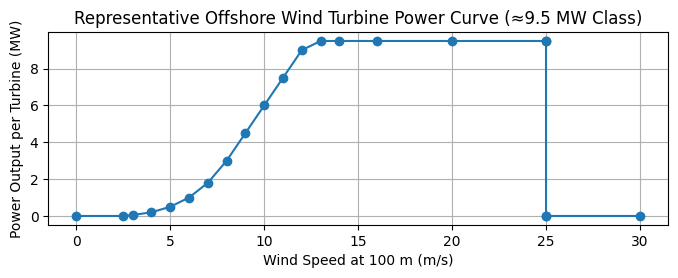

In [50]:
#add synthetic wind power with a power curve 
ws_pts = np.array([0.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                   11.0, 12.0, 13.0, 14.0, 16.0, 20.0, 24.99,24.999,25.0,25.01, 30.0], dtype="float32")
p_pts  = np.array([0.0, 0.0, 0.05, 0.20, 0.50, 1.00, 1.80, 3.00, 4.50, 6.00,
                   7.50, 9.00, 9.50, 9.50, 9.50, 9.50, 9.5,9.5,0.00,0.00, 0.00], dtype="float32")
plt.figure(figsize=(8, 2.5))
plt.plot(ws_pts, p_pts, marker='o', linestyle='-')
plt.xlabel("Wind Speed at 100 m (m/s)")
plt.ylabel("Power Output per Turbine (MW)")
plt.title("Representative Offshore Wind Turbine Power Curve (≈9.5 MW Class)")
plt.grid(True)
plt.show()
def interp_power(ws):
    return np.interp(ws, ws_pts, p_pts)

In [51]:
ws100 = cerra["ws"].sel(heightAboveGround=100.0)
synthetic_power = xr.apply_ufunc(
    np.interp,
    ws100,                # x
    xr.DataArray(ws_pts, dims="ws_pts"),
    xr.DataArray(p_pts,  dims="ws_pts"),
    input_core_dims=[[], ["ws_pts"], ["ws_pts"]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
)

In [52]:
synthetic_power.name = "synthetic_windpower"
synthetic_power.attrs = {
    "long_name": "Synthetic wind power from 100 m wind speed",
    "units": "MW per turbine",
    "description": "Derived from representative 9.5 MW-class power curve",
}

cerra = cerra.assign(synthetic_windpower=synthetic_power)

### Last tweaking and renaming

In [53]:
#flatten the height variables 
ds = cerra.copy()

# identify variables with the heightAboveGround dimension
vars_with_hag = [v for v in ds.data_vars if "heightAboveGround" in ds[v].dims]
print("Variables with heightAboveGround:", vars_with_hag)

# loop through them and split into separate variables
new_vars = {}
for v in vars_with_hag:
    for h in ds["heightAboveGround"].values:
        vname = f"{v}{int(h)}"  # e.g. ws50, ws100, wdir_cos150
        new_da = ds[v].sel(heightAboveGround=h).squeeze(drop=True)
        new_da.name = vname
        # update metadata for clarity
        new_da.attrs.update({
            "long_name": f"{v} at {int(h)} m",
            "height": int(h),
        })
        new_vars[vname] = new_da

# assign all new variables to the dataset
ds = ds.assign(**new_vars)

# drop the original 4D variables and the coordinate
ds = ds.drop_vars(vars_with_hag + ["heightAboveGround"])
ds = ds.rename({"isobaricInhPa": "level"})
cerra = ds

Variables with heightAboveGround: ['ws', 'wdir_sin', 'wdir_cos']


In [54]:
#last fixes
cerra = cerra.map(lambda x: x.astype("float32") if np.issubdtype(x.dtype, np.floating) else x)
cerra = cerra.assign_coords(
    longitude = ((cerra.longitude + 180) % 360) - 180
)

In [55]:
#convert orography to surface potential
g = 9.80665  # m s^-2 (standard gravity)
phis = (cerra["orog"].astype("float32") * g).assign_attrs(
    long_name="surface geopotential",
    units="m2 s-2",
    description="Φs = g * orography (height above mean sea level)"
)
cerra = cerra.drop_vars("orog").assign(surface_geopotential=phis)


In [56]:
cerra = cerra.rename({"si10": "ws10"})
cerra["ws10"].attrs.update({"long_name": "10 m wind speed", "units": "m s-1"})

### Sanity checks & then save

In [59]:
print(cerra.sizes)
print(cerra.coords["latitude"].min().item(), cerra.coords["latitude"].max().item())
print(cerra.coords["longitude"].min().item(), cerra.coords["longitude"].max().item())

Frozen({'y': 157, 'x': 211, 'time': 7544, 'level': 9})
48.17421306690378 56.710697262860165
-8.203234558354325 10.325340643754913


In [ ]:
cerra.to_netcdf("Cerra_boz.nc", engine="netcdf4", mode="w")

In [ ]:
cerra = cerra.chunk({"time": 24, "y": 157, "x": 211})  # or adjust chunking for your workflow
cerra.to_zarr("Cerra_boz.zarr", mode="w", consolidated=True)

In [3]:
ds=xr.open_dataset("Cerra_boz.nc")

In [5]:
ds.latitude.values

array([[48.17421307, 48.18320507, 48.19214972, ..., 48.9964755 ,
        48.99525451, 48.99398372],
       [48.22281995, 48.23182096, 48.24077458, ..., 49.04591476,
        49.04469252, 49.04342043],
       [48.27142646, 48.28043649, 48.28939908, ..., 49.09535469,
        49.0941312 , 49.09285782],
       ...,
       [55.63103378, 55.64156019, 55.65203163, ..., 56.59560173,
        56.59416638, 56.59267249],
       [55.67909733, 55.6896348 , 55.70011725, ..., 56.64469576,
        56.64325885, 56.64176334],
       [55.72715396, 55.73770251, 55.74819598, ..., 56.69378445,
        56.69234598, 56.69084884]])

In [6]:
ds.longitude.values

array([[-5.71701353, -5.64411178, -5.57118381, ...,  9.80915486,
         9.88450507,  9.95985146],
       [-5.73054614, -5.6575757 , -5.58457897, ...,  9.8109797 ,
         9.88640585,  9.96182817],
       [-5.74410517, -5.67106593, -5.5980003 , ...,  9.81280822,
         9.88831047,  9.96380887],
       ...,
       [-8.16575863, -8.08059072, -7.99538042, ..., 10.14145035,
        10.23062564, 10.31979458],
       [-8.18447524, -8.0992149 , -8.01391203, ..., 10.14400738,
        10.23328903, 10.3225643 ],
       [-8.20323456, -8.1178816 , -8.03248598, ..., 10.14657052,
        10.23595878, 10.32534064]])